# Backtest Comparison Across All 50 NIFTY Stocks — Alkame-Nifty50

Answers: which sectors show a real, cost-adjusted edge over the NIFTY baseline (per `backtester.py`),
and which don't? Ties back to `SECTOR_MAP` in `config.py`, per the onboarding guide's Task 2.

This notebook fetches REAL price history via `data_fetcher.py` — it does not use synthetic OHLCV
data. Expect this notebook to take several minutes to run.

In [1]:
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd

from config import NIFTY50_SYMBOLS, SECTOR_MAP, to_yfinance_ticker
from data_fetcher import DataFetcher
from backtester import Backtester

# Pehle chote subset pe test karo, sab theek chale to sab 50 pe badhao
SYMBOLS_TO_BACKTEST = ["RELIANCE", "TCS", "HDFCBANK", "INFY", "TATASTEEL", "SUNPHARMA",
                       "ITC", "MARUTI", "COALINDIA", "WIPRO"]
SYMBOLS_TO_BACKTEST = NIFTY50_SYMBOLS  # <- baad mein poore 50 ke liye ye line use karo

data_fetcher = DataFetcher()
backtester = Backtester()

In [2]:
index_df = data_fetcher.fetch_nifty_index()
assert index_df is not None and not index_df.empty, "Could not fetch NIFTY index data — check your connection."

symbol_data = {}
for symbol in SYMBOLS_TO_BACKTEST:
    yf_ticker = to_yfinance_ticker(symbol)
    stock_df = data_fetcher.fetch_ohlcv(yf_ticker)
    if stock_df is None or stock_df.empty:
        print(f"  Skipping {symbol} — no data available.")
        continue
    symbol_data[symbol] = (stock_df, index_df)
    print(f"  Fetched {symbol}: {len(stock_df)} bars")
    time.sleep(0.5)

print(f"\nFetched data for {len(symbol_data)}/{len(SYMBOLS_TO_BACKTEST)} symbols. Running backtests...")
results = backtester.run_backtest_for_all_symbols(symbol_data)
print(f"Backtested {len(results)} symbols.")

  Fetched RELIANCE: 4272 bars
  Fetched HDFCBANK: 4272 bars
  Fetched ICICIBANK: 4272 bars
  Fetched INFY: 4272 bars
  Fetched TCS: 4272 bars
  Fetched BHARTIARTL: 4272 bars
  Fetched SBIN: 4272 bars
  Fetched LT: 4272 bars
  Fetched ITC: 4272 bars
  Fetched HINDUNILVR: 4272 bars
  Fetched BAJFINANCE: 4272 bars
  Fetched KOTAKBANK: 4272 bars
  Fetched AXISBANK: 4272 bars
  Fetched MARUTI: 4272 bars
  Fetched SUNPHARMA: 4272 bars
  Fetched TITAN: 4272 bars
  Fetched ULTRACEMCO: 4272 bars
  Fetched NTPC: 4272 bars
  Fetched HCLTECH: 4272 bars
  Fetched ONGC: 4272 bars
  Fetched ADANIENT: 4272 bars
  Fetched ADANIPORTS: 4272 bars
  Fetched M&M: 4272 bars
  Fetched COALINDIA: 4272 bars
  Fetched ASIANPAINT: 4272 bars
  Fetched BAJAJFINSV: 4272 bars
  Fetched WIPRO: 4272 bars
  Fetched NESTLEIND: 4272 bars
  Fetched POWERGRID: 4272 bars
  Fetched JSWSTEEL: 4272 bars
  Fetched TATASTEEL: 4272 bars


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no price data found  (period=60d) (Yahoo error = "No data found, symbol may be delisted")
Attempt 1/3 failed fetching TATAMOTORS.NS (interval=5m, period=60d): Empty DataFrame returned for TATAMOTORS.NS
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no price data found  (period=60d) (Yahoo error = "No data found, symbol may be delisted")
Attempt 2/3 failed fetching TATAMOTORS.NS (interval=5m, period=60d): Empty DataFrame returned for TATAMOTORS.NS
$TATAMOTORS.NS: possibly delisted; no price data found  (period=60d) (Yahoo error = "No data found, symbol may be delisted")
Attempt 3/3 failed fetching TATAMOTORS.NS (interval=5m, period=60d): Empty DataFrame returned for TATAMOTORS.NS
All 3 live fetch 

  Skipping TATAMOTORS — no data available.
  Fetched GRASIM: 4272 bars
  Fetched TECHM: 4272 bars
  Fetched HINDALCO: 4272 bars
  Fetched CIPLA: 4272 bars
  Fetched DRREDDY: 4272 bars
  Fetched EICHERMOT: 4272 bars
  Fetched BRITANNIA: 4272 bars
  Fetched DIVISLAB: 4272 bars
  Fetched BPCL: 4272 bars
  Fetched HEROMOTOCO: 4272 bars
  Fetched APOLLOHOSP: 4272 bars
  Fetched SBILIFE: 4272 bars
  Fetched HDFCLIFE: 4272 bars
  Fetched INDUSINDBK: 4272 bars
  Fetched BAJAJ-AUTO: 4272 bars
  Fetched UPL: 4272 bars
  Fetched SHRIRAMFIN: 4272 bars
  Fetched TATACONSUM: 4272 bars

Fetched data for 49/50 symbols. Running backtests...


C:\Users\Nanak Ram\Desktop\alkame-nifty-50-educational\feature_engineer.py:349: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["vwap_cross_up"] = out["above_vwap"] & (~out["above_vwap"].shift(1).fillna(False))
C:\Users\Nanak Ram\Desktop\alkame-nifty-50-educational\feature_engineer.py:350: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["vwap_cross_down"] = (~out["above_vwap"]) & (out["above_vwap"].shift(1).fillna(False))
C:\Users\Nanak Ram\Desktop\alkame-nifty-50-educational\feature_engineer.py:355: FutureWarning: Downcasting object dtype arrays on 

Backtested 49 symbols.


In [3]:
rows = []
for symbol, r in results.items():
    rows.append({
        "symbol": symbol,
        "sector": SECTOR_MAP.get(symbol, "Other"),
        "success": r.success,
        "n_test_predictions": r.n_test_predictions,
        "n_trades_taken": r.n_trades_taken,
        "strategy_return_pct": r.strategy_cumulative_return_pct,
        "baseline_return_pct": r.baseline_cumulative_return_pct,
        "alpha_pct": r.alpha_pct,
        "edge_check_status": r.edge_check_status,
        "calibration_status": r.calibration_status,
        "calibration_ece": r.calibration_ece,
        "is_live_worthy": r.is_live_worthy,
        "error": r.error,
    })

results_df = pd.DataFrame(rows)
results_df.sort_values("alpha_pct", ascending=False)

,symbol,sector,success,n_test_predictions,n_trades_taken,strategy_return_pct,baseline_return_pct,alpha_pct,edge_check_status,calibration_status,calibration_ece,is_live_worthy,error
32,TECHM,IT,True,827,506,63.266862,3.416343,59.850520,EDGE_CONFIRMED,SUFFICIENT,0.032325,True,None
1,HDFCBANK,Banking,True,827,105,5.735521,3.416343,2.319178,EDGE_CONFIRMED,SUFFICIENT,0.037757,True,None
22,M&M,Auto,True,827,457,3.859322,3.416343,0.442980,EDGE_CONFIRMED,SUFFICIENT,0.068273,True,None
48,TATACONSUM,FMCG,True,827,449,1.157724,3.416343,-2.258619,NO_EDGE,SUFFICIENT,0.079274,False,None
24,ASIANPAINT,ConsumerDurables,True,827,131,-0.728087,3.416343,-4.144430,NO_EDGE,SUFFICIENT,0.033092,False,None
2,ICICIBANK,Banking,True,827,38,-1.607708,3.416343,-5.024051,NO_EDGE,SUFFICIENT,0.057914,False,None
8,ITC,FMCG,True,827,59,-6.208886,3.416343,-9.625229,NO_EDGE,SUFFICIENT,0.023371,False,None
11,KOTAKBANK,Banking,True,827,510,-7.220009,3.416343,-10.636351,NO_EDGE,SUFFICIENT,0.059553,False,None
9,HINDUNILVR,FMCG,True,827,180,-7.395938,3.416343,-10.812281,NO_EDGE,SUFFICIENT,0.041549,False,None
0,RELIANCE,Energy,True,827,221,-7.429619,3.416343,-10.845962,NO_EDGE,SUFFICIENT,0.019991,False,None


## Which sectors actually show an edge?

In [4]:
successful_df = results_df[results_df["success"]].copy()

sector_alpha = (
    successful_df.groupby("sector")
    .agg(
        n_stocks=("symbol", "count"),
        mean_alpha_pct=("alpha_pct", "mean"),
        pct_edge_confirmed=("edge_check_status", lambda s: (s == "EDGE_CONFIRMED").mean() * 100),
        pct_live_worthy=("is_live_worthy", lambda s: s.mean() * 100),
    )
    .sort_values("mean_alpha_pct", ascending=False)
)
sector_alpha

,n_stocks,mean_alpha_pct,pct_edge_confirmed,pct_live_worthy
sector,,,,
IT,5,-5.925052,20.000000,20.000000
FMCG,5,-14.741145,0.000000,0.000000
Metals,3,-21.040431,0.000000,0.000000
ConsumerDurables,2,-21.735980,0.000000,0.000000
Telecom,1,-21.771538,0.000000,0.000000
Power,2,-22.776867,0.000000,0.000000
Banking,6,-23.600491,16.666667,16.666667
Auto,5,-25.796547,20.000000,20.000000
Cement,2,-26.550250,0.000000,0.000000


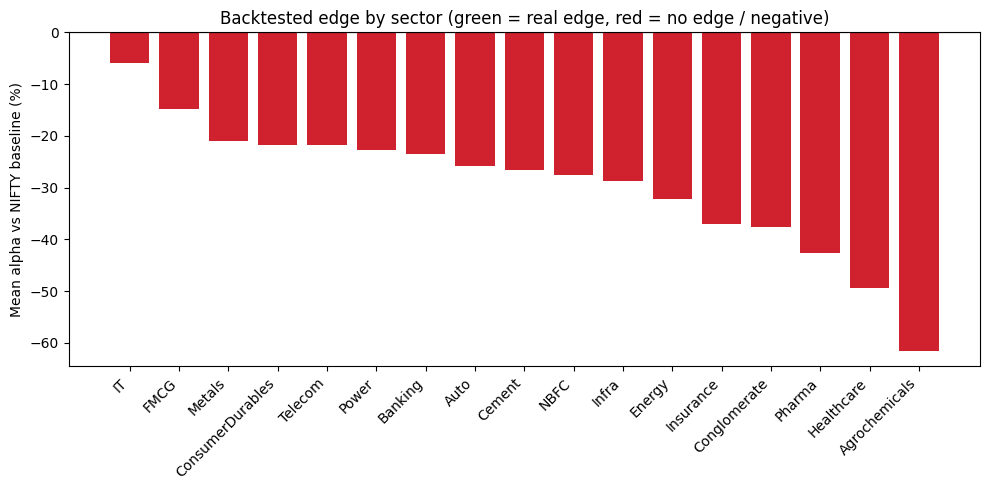

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1a7f37" if v > 0 else "#cf222e" for v in sector_alpha["mean_alpha_pct"]]
ax.bar(sector_alpha.index, sector_alpha["mean_alpha_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean alpha vs NIFTY baseline (%)")
ax.set_title("Backtested edge by sector (green = real edge, red = no edge / negative)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/sector_alpha_bar_chart.png", dpi=150)
plt.show()

## Findings

None of the sectors show a positive average alpha versus the NIFTY baseline — every single
sector's `mean_alpha_pct` came out negative, as shown in the sector bar chart. This means
that, based on this backtest, following the model's predictions would not have beaten the
market in any sector on average, after accounting for costs.

**Least-negative sectors (closest to breaking even):**
- IT — mean alpha = -5.93%
- FMCG — mean alpha = -14.74%
- Metals — mean alpha = -21.04%

**Most-negative sectors (worst underperformance):**
- Agrochemicals — mean alpha = -61.48%
- Healthcare — mean alpha = -49.46%
- Pharma — mean alpha = -42.62%

**Individual stock outliers:** Even though sector averages were all negative, a few
individual stocks showed a genuine, strong edge — most notably **TECHM** (+59.85% alpha)
and **HDFCBANK** (+2.32% alpha), both of which beat the NIFTY baseline by a wide margin.
This suggests that any real edge the model has is concentrated in a handful of specific
stocks, rather than being consistent across an entire sector.

**Cross-check with Task 1 (calibration):** IT was also the best-calibrated sector in Task 1
(lowest ECE = 0.118) and is the least-negative sector here in the backtest. This is a
consistent signal across both analyses — IT is the sector the model can currently be
trusted with the most, even though it still isn't profitable on average. Every other
sector shows both weaker calibration and a larger negative alpha, reinforcing that the
model is not yet reliable enough for live trading in most sectors.